# 02 — Correlation Analysis

Examines the correlation structure of candidate predictors within each analysis arm,
separately, before hypothesis testing and regression:

- **Environmental arm:** the 9 ward colonization-pressure variables (`{pathogen}_cp`) —
  both their relationship with MRSA acquisition and with each other (multicollinearity).
- **Patient arm:** the antibiotic-class course-count variables (`{abx_class}_0_60`) —
  same two questions.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import pointbiserialr

sys.path.append(str(Path.cwd().parent))
from src.data_loading import load_processed, drop_zero_variance

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

env = load_processed("environmental_mrsa.csv")
pat = load_processed("patient_mrsa.csv")

## Environmental: colonization pressure correlations

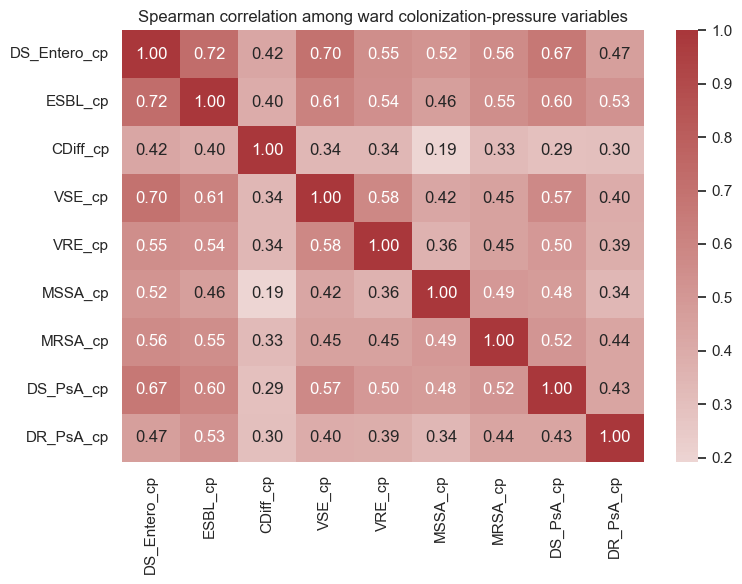

In [2]:
cp_cols = [c for c in env.columns if c.endswith("_cp")]

corr = env[cp_cols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, cmap="vlag", center=0, annot=True, fmt=".2f", ax=ax)
ax.set_title("Spearman correlation among ward colonization-pressure variables")
plt.tight_layout()

In [3]:
# Point-biserial correlation of each CP variable with case/control status
results = []
for c in cp_cols:
    r, p = pointbiserialr(env["group_binary"], env[c])
    results.append({"variable": c, "r": r, "p": p})
pd.DataFrame(results).sort_values("r", ascending=False)

,variable,r,p
6,MRSA_cp,0.015007,0.374927
4,VRE_cp,0.002817,0.867727
8,DR_PsA_cp,-0.001172,0.944742
7,DS_PsA_cp,-0.016243,0.336846
5,MSSA_cp,-0.016814,0.320133
2,CDiff_cp,-0.018350,0.277923
1,ESBL_cp,-0.038321,0.023422
3,VSE_cp,-0.039179,0.020489
0,DS_Entero_cp,-0.058341,0.000556


## Patient: antibiotic exposure correlations

Dropping 'carbapenem_0_60': zero variance in this subset (no exposed cases).


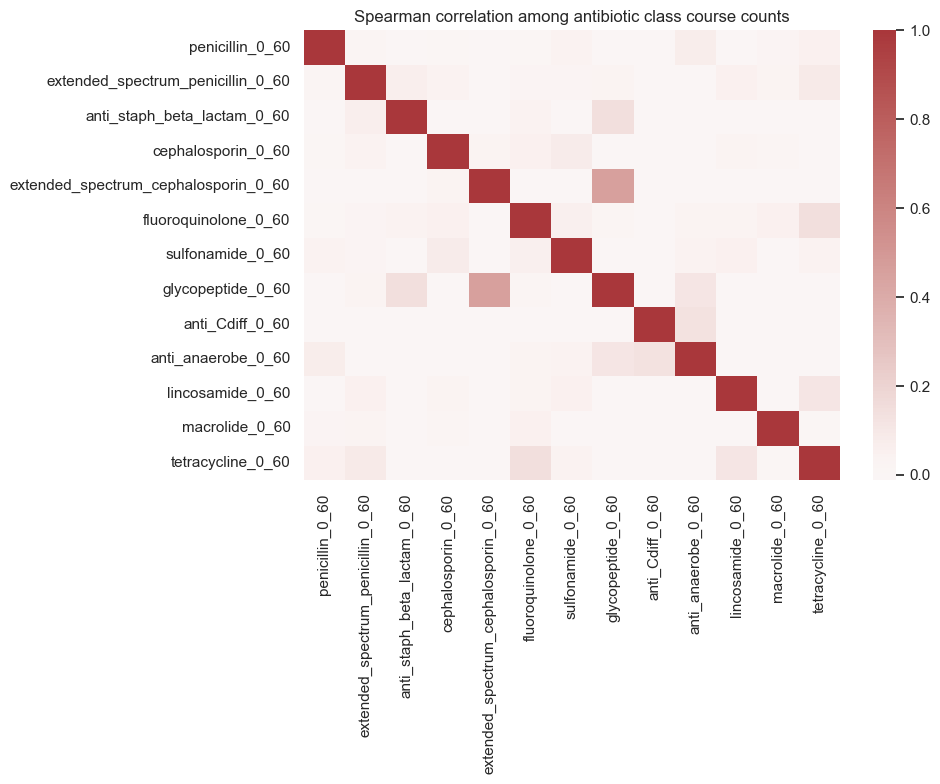

In [4]:
abx_cols = [c for c in pat.columns if c.endswith("_0_60") and c != "any_abx_0_60"]
abx_cols = drop_zero_variance(pat, abx_cols)

corr = pat[abx_cols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap="vlag", center=0, ax=ax)
ax.set_title("Spearman correlation among antibiotic class course counts")
plt.tight_layout()

In [5]:
results = []
for c in abx_cols:
    r, p = pointbiserialr(pat["group_binary"], pat[c])
    results.append({"variable": c, "r": r, "p": p})
pd.DataFrame(results).sort_values("r", ascending=False)

,variable,r,p
7,glycopeptide_0_60,0.014784,0.364911
5,fluoroquinolone_0_60,-0.004565,0.779678
8,anti_Cdiff_0_60,-0.005825,0.721097
10,lincosamide_0_60,-0.009076,0.578081
4,extended_spectrum_cephalosporin_0_60,-0.010893,0.504395
11,macrolide_0_60,-0.010910,0.503757
9,anti_anaerobe_0_60,-0.017714,0.277639
0,penicillin_0_60,-0.017722,0.277414
12,tetracycline_0_60,-0.019270,0.237588
2,anti_staph_beta_lactam_0_60,-0.019867,0.223378


## Notes for the regression stage

Flag any predictor pairs with |Spearman r| > ~0.7 here — they're multicollinearity
candidates worth checking with VIF in `04a`/`04b` rather than dropping outright.